In [18]:
# import packages
import os
import numpy as np
import netCDF4 as nc
import datetime as dt
import sys
from glob import glob
import matplotlib.pyplot as plt
import calendar
import numpy.ma as ma
import string
import matplotlib.cm as cmap
from scipy import integrate
from scipy import interpolate
from scipy import stats
from matplotlib.ticker import NullFormatter
import scipy
from scipy import signal
import xarray as xr
from tqdm import tqdm
from beam_model import beam_model_calc,eval_es,eval_theta_e,eval_q,eval_qs

In [20]:
# constants
rd = 287.04 # gas constant of dry air
rv = 461.50 # gas constant of water vapor
cvd = 719. # heat capacity at constant volume for dry air
cpd = 1005.7 # heat capacity at constant pressure for dry air
cvv = 1410. # heat capacity at constant volume of water vapor
cpv = 1870. # heat capacity at constant pressure of water vapor
cl = 4190. # heat capacity of liquid water (above freezing)
cpi = 2093.
cpvmcl = cl-cpv # cpvmcl seems to be a common notation for this value

# Units: dimensionless
epsilon = rd/rv

# Units: J/Kg
lv0 = 2.501E6 # latent heat of vaporization at 0-deg-C
ls = 2.834E6 # latent heat of sublimation (-100<=T<= 0-deg-C)
lf = 0.3337E6 # latent heat of fusion at 0-deg-C (lv0-ls)

# Units: m/s**2
g = 9.80665 # standard gravity

In [22]:
region = 2 
pr_thresh=0.5

In [23]:

import numpy.ma as ma
# see conditions below for lat and lon bounded regions: 1 Pacific, 2 West Pacific, 3 East Pacific
region = 2
# f = nc.Dataset('COSMIC2_IMERG_profiles_2019_001-2022_274.nc','r')
f = nc.Dataset('COSMIC2_interp25hpa.nc','r')

lat = f.variables['lat'][:]
lon = f.variables['lon'][:]
if region == 1:
    reg = ' Pac, 120E - 80W'
    pacinds = np.logical_and(np.logical_or(lon<=-80,lon>=120),np.logical_and(lat<=15,lat>=-15))
elif region == 2:
    reg = ' W Pac, 120E - 140W, 15S - 15N'
    pacinds = np.logical_and(np.logical_or(lon<=-140,lon>=120),np.logical_and(lat<=15,lat>=-15))
elif region == 3:
    reg = ' E Pac, 150W - 80W'
    pacinds = np.logical_and(np.logical_and(lon<=-80,lon>=-90),np.logical_and(lat<=15,lat>=-15))




t_end = f.variables['time'].shape[0]
f_pr = nc.Dataset('COSMIC2_IMERG_match_021325.nc','r')
bl_qc = f.variables['boundary_layer_qc'][:]
qc_inds = np.logical_and(pacinds,np.logical_not(bl_qc))

pr_ev = ma.getdata(f_pr.variables['pr_prof'][qc_inds])
pr_t = f_pr.variables['hour'][:]
pr = pr_ev[:,pr_t==0].squeeze()

In [25]:
# load vars
lev = f.variables['lev'][:]
levh=lev/100
theta_e = f.variables['theta_e_env'][:][qc_inds]
theta_es = f.variables['theta_es_env'][:][qc_inds]
# theta_e_tilde = f.variables['theta_e_tilde'][:]#[qc_inds]
# q_tilde = f.variables['q_tilde'][:]#[qc_inds]
# q_bl = f.variables['q_bl'][:]#[qc_inds]
# theta_e_bl = f.variables['theta_e_bl'][:]#[qc_inds]
q_env = f.variables['q_env'][:][qc_inds]
ta_env = f.variables['ta_env'][:][qc_inds]
qs_env = f.variables['qs_env'][:][qc_inds]

In [26]:
lft_t = np.argmin(lev>600e2)

uft_ind = np.argmin(lev>=600e2)
uft_t_ind = np.argmin(lev>=200e2)

lft_b = np.argmin(lev>900e2)
bl_t = np.argmin(lev>900e2)

In [28]:
from scipy.signal import convolve
# define event hour to calculate accumulation
event_hr = 1


window = 2
k = np.ones(window) / window

y = convolve(pr_ev[:,np.logical_and(pr_t<0,pr_t>-6)], k[None, :],mode='same')
# trans = np.sum(pr_ev[:,np.logical_and(pr_t<event_hr,pr_t>=0)]>=pr_thresh,axis=1)>0
trans = np.sum(pr_ev[:,np.logical_and(pr_t<event_hr,pr_t>=0)]/2,axis=1)>=pr_thresh
rainfree_id = (y > pr_thresh).any(axis=1)
# rainfree_id = np.sum(pr_ev[:,np.logical_and(pr_t<0,pr_t>-6)]>=pr_thresh,axis=1)<1
trans_inds = np.logical_and(trans,rainfree_id)
rainfree = np.logical_and(rainfree_id,~trans)

beg_num = np.argmin(pr_ev[trans_inds][:,np.logical_and(pr_t<event_hr,pr_t>=0)]<pr_thresh,axis=1)
# beg_inds = beg_num+24
beg_inds = trans

In [32]:
# 1st hour precip
pr_accum_hr =np.nansum(pr_ev[:,np.logical_and(pr_t<event_hr,pr_t>=0)]/2,axis=1)


In [35]:
l_eff_full = lam(ta_env)*ls(ta_env) + (1-lam(ta_env))*lv(ta_env)
kap_full         = 1+l_eff_full**2*qs_env/cpd/rv/ta_env/T0
es_rho = theta_es*(1 + kap_full*0.61*q_env)

In [36]:
from scipy.interpolate import interp1d, CubicSpline
# levs = np.linspace(1000e2,200e2,1000)
levs = np.arange(1000e2,200e2,-500)
levh = levs/100
# interpolate mean profiles using cubic spline
# es_interp  = np.interp(levs,np.flipud(lev),np.flipud(theta_es))
# e_interp  = np.interp(levs,np.flipud(lev),np.flipud(theta_e))
# q_interp  = np.interp(levs,np.flipud(lev),np.flipud(q))
# ta_interp  = np.interp(levs,np.flipud(lev),np.flipud(ta_full))

lev_inc = np.flipud(lev)
# es_rho_beg = np.nanmean(,axis=0)
es_beg = np.nanmean(theta_es[beg_inds],axis=0)
e_beg = np.nanmean(theta_e[beg_inds],axis=0)
q_beg = np.nanmean(q_env[beg_inds],axis=0)
ta_beg = np.nanmean(ta_env[beg_inds],axis=0)

f_es = CubicSpline(lev_inc,np.flipud(es_beg))
f_e = CubicSpline(lev_inc,np.flipud(e_beg))
f_q = CubicSpline(lev_inc,np.flipud(q_beg))
f_ta = CubicSpline(lev_inc,np.flipud(ta_beg))

# f_lwc = interp1d(lev,lwc , axis=1, bounds_error=False, fill_value="extrapolate")
# f_iwc = interp1d(lev,ice , axis=1, bounds_error=False, fill_value="extrapolate")

es_ref = f_es(levs)
# es_interp = f_es(levs)
e_ref = f_e(levs)
q_ref = f_q(levs)
ta_ref = f_ta(levs)
# lwc_interp = f_lwc(levs)  # → shape (800, 100)
# iwc_interp = f_iwc(levs) 




# e_ref = np.interp(levs,np.flipud(lev),np.flipud(np.nanmean(theta_e[beg_inds],axis=0)))
# es_ref = np.interp(levs,np.flipud(lev),np.flipud(np.nanmean(theta_es[beg_inds],axis=0)))
# ta_ref = np.interp(levs,np.flipud(lev),np.flipud(np.nanmean(ta_full[beg_inds],axis=0)))
# q_ref = np.interp(levs,np.flipud(lev),np.flipud(np.nanmean(q[beg_inds],axis=0)))

qs_ref = eval_qs(ta_ref,levs)
l_eff = lam(ta_ref)*ls(ta_ref) + (1-lam(ta_ref))*lv(ta_ref)
kap          = 1+l_eff**2*qs_ref/cpd/rv/ta_ref/T0


# flwc = interp1d(lev,lwc[beg_inds] , axis=1, bounds_error=False, fill_value="extrapolate")
# fiwc = interp1d(lev,ice[beg_inds], axis=1, bounds_error=False, fill_value="extrapolate")


# lwc = flwc(levs)  # → shape (800, 100)
# iwc = fiwc(levs) 



# lwc_ev = scipy.interpolate.interp2d(levs,np.flipud(lev),np.flipud(lwc[beg_inds]))
# iwc_ev = scipy.interpolate.interp2d(levs,np.flipud(lev),np.flipud(ice[beg_inds]))

In [39]:
# Set up mixing coefficients for the model
e_hat = 1
pb = 900e2
pl = 600e2
lft = np.logical_and(levs<pb,levs>=pl)


c_mix = 1/(levs - levs[0])
c_mix[0] = 0
c_mix[levh<=600] = 0

c_nomix = np.copy(c_mix)
c_nomix[levs<=pb] = 0
c_mix[levs<=pb] = c_mix[levs<=pb]*e_hat

/tmp/ipykernel_2543662/3597769192.py:8: RuntimeWarning: divide by zero encountered in divide
  c_mix = 1/(levs - levs[0])


In [50]:
# constraint from ARM notebook, pasted here for ease
arm1 = np.array([350.46964568, 350.46964568, 350.41842085, 350.38077167,
       350.33455132, 350.27935094, 350.21476276, 350.14038002,
       350.05579686, 349.96060797, 349.8544082 , 349.73679192,
       349.60755421, 349.48226348, 349.34721149, 349.20395164,
       349.05465621, 348.90159014, 348.74659679, 348.59109958,
       348.43621251, 348.28281737, 348.09454441, 347.91145826,
       347.73354439, 347.56064532, 347.3924898 , 347.22874507,
       347.06914378, 346.91349979, 346.76169378, 346.61366181,
       346.46937365, 346.32877872, 346.19179731, 346.05832491,
       345.92823268, 345.80135785, 345.67741781, 345.55600807,
       345.43661781, 345.31864292, 345.20147436, 345.08480057,
       344.96864665, 344.85333639, 344.73945944, 344.62775057,
       344.51871249, 344.41255124, 344.30920635, 344.20837715,
       344.10960874, 344.01255305, 343.91701938, 343.82296   ,
       343.7304574 , 343.63967313, 343.55068448, 343.46345299,
       343.37783402, 343.29358521, 343.21041128, 343.12811444,
       343.04662305, 342.96598225, 342.88634546, 342.8079413 ,
       342.73096794, 342.65557041, 342.58184437, 342.50983932,
       342.43956708, 342.37102525, 342.30420336, 342.23908346,
       342.17564061, 342.11385788, 342.05378341, 341.99554082,
       341.93932484, 341.97439804, 342.00976398, 342.04542323,
       342.08137615, 342.11762292, 342.15416353, 342.19099772,
       342.22812501, 342.2430962 , 342.26018405, 342.27939478,
       342.30072046, 342.32415269, 342.34968263, 342.37730095,
       342.40699782, 342.43876286, 342.47258513, 342.50845301,
       342.54635419, 342.58627561, 342.62820333, 342.67212247,
       342.71801712, 342.7658702 , 342.81566334, 342.86737676,
       342.92098907, 342.97647716, 343.03381596, 343.09297827,
       343.1539345 , 343.21665247, 343.28109712, 343.34723024,
       343.41501014, 343.48439136, 343.55532428, 343.62775479,
       343.70162384, 343.77686709, 343.85341443, 343.93118957,
       344.01010955, 344.09008432, 344.17101624, 344.25279968,
       344.33532053, 344.41845588, 344.50207363, 344.58603225,
       344.67018059, 344.75435782, 344.83839348, 344.92210777,
       345.00531194, 345.08780901, 345.16939466, 345.24985844,
       345.3289853 , 345.40655741, 345.48235632, 345.55616536,
       345.62777246, 345.69697306, 345.76357331, 345.82739327,
       345.8882702 , 345.94606168, 346.00035851, 346.05057451,
       346.09665587, 346.13880758, 346.17723453, 346.21214153,
       346.24373292, 346.27221222, 346.29778135, 346.32063994])

arm2 = np.array([350.46964568, 350.46964568, 350.41842085, 350.38077167,
       350.33455132, 350.27935094, 350.21476276, 350.14038002,
       350.05579686, 349.96060797, 349.8544082 , 349.73679192,
       349.60755421, 349.47530148, 349.33308877, 349.18263582,
       349.02612673, 348.86582556, 348.70357433, 348.54079077,
       348.37859386, 348.21786754, 348.11568875, 348.01354805,
       347.91183731, 347.81080683, 347.71059158, 347.61124839,
       347.51283381, 347.41541982, 347.31909145, 347.22394483,
       347.13007877, 347.03756798, 346.94646001, 346.85677889,
       346.76852818, 346.68168166, 346.5961404 , 346.51173006,
       346.42820957, 346.34527855, 346.26262619, 346.18009846,
       346.0977223 , 346.0156873 , 345.93432961, 345.85406732,
       345.77519437, 345.69784364, 345.62200159, 345.54752135,
       345.4741687 , 345.40176471, 345.33021432, 345.25949936,
       345.18967247, 345.12082966, 345.05302087, 344.98623231,
       344.9203912 , 344.85537001, 344.79101059, 344.72720605,
       344.66391692, 344.60116659, 344.53903723, 344.47765237,
       344.41712052, 344.35752281, 344.29891475, 344.2413278 ,
       344.18477341, 344.12925464, 344.07476923, 344.02130995,
       343.96886485, 343.91742569, 343.86701988, 343.81771657,
       343.76962441, 343.78876603, 343.80806005, 343.82750687,
       343.84710685, 343.86686022, 343.88676716, 343.90682772,
       343.92704185, 343.94740941, 343.9679301 , 343.98860351,
       344.07069733, 344.15264489, 344.2346346 , 344.31669385,
       344.39885106, 344.4811355 , 344.56357717, 344.64620659,
       344.72905473, 344.81215278, 344.89553202, 344.97922367,
       345.06325867, 345.14766752, 345.2324801 , 345.31772548,
       345.40343165, 345.48962537, 345.57633189, 345.66357473,
       345.75137537, 345.839753  , 345.92872422, 346.0183027 ,
       346.10849883, 346.19931935, 346.290767  , 346.38284003,
       346.47553179, 346.56883028, 346.66271759, 346.75716942,
       346.85215452, 346.94763409, 347.04356123, 347.13988031,
       347.23652636, 347.33342447, 347.43048923, 347.52762414,
       347.6247211 , 347.72166004, 347.81830851, 347.91452155,
       348.0101416 , 348.10499867, 348.19891077, 348.29168455,
       348.38311631, 348.47299337, 348.5610958 , 348.64719858,
       348.73107417, 348.81249551, 348.89123935, 348.96708999,
       349.03984317, 349.10931017, 349.17532187, 349.23773268,
       349.2958994 , 349.3492292 , 349.39794966, 349.44230454,
       349.48253678, 349.51888852, 349.55160062, 349.58091209])
# ARM quantities for comparison
arm_e = np.array([350.4682858 , 350.41716655, 350.34189294, 350.24084477,
       350.11240184, 349.95494397, 349.76685094, 349.54650257,
       349.29227867, 349.00255902, 348.67572344, 348.31237601,
       347.92201789, 347.51637452, 347.10717135, 346.70613382,
       346.32301201, 345.95965455, 345.61593471, 345.29172576,
       344.98690096, 344.70086639, 344.43115934, 344.1748499 ,
       343.92900818, 343.69070426, 343.45765112, 343.23013323,
       343.00907796, 342.79541265, 342.59006466, 342.3936639 ,
       342.2056505 , 342.02516714, 341.85135651, 341.6833613 ,
       341.51965108, 341.35600305, 341.18752127, 341.00930984,
       340.81647282, 340.60672427, 340.38821807, 340.17171806,
       339.96798808, 339.78779199, 339.63844698, 339.51348372,
       339.40298621, 339.29703847, 339.18572451, 339.06172407,
       338.92809973, 338.79050983, 338.65461266, 338.52606655,
       338.40871705, 338.29915867, 338.19217313, 338.0825422 ,
       337.9650476 , 337.83628441, 337.70010106, 337.5621593 ,
       337.42812088, 337.30364757, 337.19310362, 337.09566329,
       337.00920332, 336.93160049, 336.86073153, 336.79473149,
       336.73276848, 336.67426892, 336.61865919, 336.56536571,
       336.51474149, 336.47084608, 336.43866564, 336.42318635,
       336.42939435, 336.46071386, 336.51432119, 336.5858307 ,
       336.67085673, 336.76501365, 336.86437333, 336.96683769,
       337.07076621, 337.17451833, 337.27645351, 337.37510021,
       337.46966296, 337.55951529, 337.64403072, 337.72258279,
       337.79495807, 337.86259532, 337.92734635, 337.99106297,
       338.05559699, 338.12315748, 338.19738255, 338.28226759,
       338.38180798, 338.4999991 , 338.6389269 , 338.79303965,
       338.9548762 , 339.11697539, 339.27187607, 339.41467477,
       339.5506988 , 339.68783314, 339.83396281, 339.9969728 ,
       340.18226468, 340.38530639, 340.59908243, 340.81657732,
       341.03077556, 341.23621285, 341.4336295 , 341.62531704,
       341.81356697, 342.00067079, 342.18867914, 342.37867915,
       342.5715171 , 342.76803924, 342.96909186, 343.17508978,
       343.38472212, 343.59624656, 343.80792078, 344.01800245,
       344.22528803, 344.43072897, 344.6358155 , 344.84203785,
       345.05088624, 345.26334691, 345.47839009, 345.69448205,
       345.91008902, 346.12367728, 346.33396843, 346.5407056 ,
       346.74388725, 346.94351189, 347.13957799, 347.33247718,
       347.52417359, 347.71702454, 347.91338729, 348.11561914,
       348.32535956, 348.54137675, 348.76172111, 348.98444302])
arm_es = np.array([361.13695454, 360.63634815, 360.06279976, 359.4302685 ,
       358.7527135 , 358.0440939 , 357.31836882, 356.5894974 ,
       355.87143878, 355.17815208, 354.52359644, 353.91819402,
       353.35821904, 352.83640877, 352.34550045, 351.87823135,
       351.42906977, 350.99940827, 350.59237044, 350.21107989,
       349.85866022, 349.53675912, 349.24112068, 348.96601305,
       348.7057044 , 348.4544629 , 348.20780887, 347.96627128,
       347.73163125, 347.5056699 , 347.29016835, 347.08700358,
       346.89843593, 346.72682163, 346.57451688, 346.44387788,
       346.33587225, 346.2459133 , 346.16802572, 346.09623422,
       346.02456352, 345.9484995 , 345.86937284, 345.78997541,
       345.71309905, 345.64153564, 345.57705554, 345.51734308,
       345.45906114, 345.39887255, 345.33344016, 345.26066478,
       345.18339903, 345.10573347, 345.03175869, 344.96556525,
       344.90991772, 344.86227663, 344.81877654, 344.77555196,
       344.72873743, 344.67486721, 344.61207446, 344.53889207,
       344.45385292, 344.35548989, 344.24345129, 344.12184714,
       343.99590286, 343.87084391, 343.75189572, 343.64270095,
       343.54057115, 343.44123509, 343.34042153, 343.23385926,
       343.11882336, 342.99877414, 342.87871827, 342.76366238,
       342.65861311, 342.56832192, 342.49651951, 342.44668138,
       342.42228305, 342.42680002, 342.46155919, 342.51929309,
       342.59058561, 342.66602067, 342.73618217, 342.79394807,
       342.84137245, 342.88280347, 342.92258924, 342.96507792,
       343.01393485, 343.07009419, 343.13380735, 343.20532569,
       343.2849006 , 343.37216409, 343.46427069, 343.55775554,
       343.64915379, 343.73500058, 343.81296048, 343.88521564,
       343.95507765, 344.02585807, 344.1008685 , 344.18266074,
       344.27074756, 344.36388197, 344.46081698, 344.56030559,
       344.66099044, 344.76107263, 344.85864288, 344.95179193,
       345.0386105 , 345.11777701, 345.19032073, 345.2578586 ,
       345.32200759, 345.38438464, 345.44636438, 345.50835212,
       345.5705108 , 345.6330034 , 345.69599288, 345.75969218,
       345.82451405, 345.89092125, 345.9593765 , 346.03034255,
       346.10438077, 346.1824471 , 346.26559612, 346.3548824 ,
       346.45136053, 346.55562807, 346.66645448, 346.78215219,
       346.90103365, 347.02141131, 347.14201834, 347.2632709 ,
       347.38600589, 347.51106022, 347.63927079, 347.77161754,
       347.90965262, 348.05507125, 348.20956863, 348.37483995,
       348.55188646, 348.73893358, 348.93351274, 349.13315539])

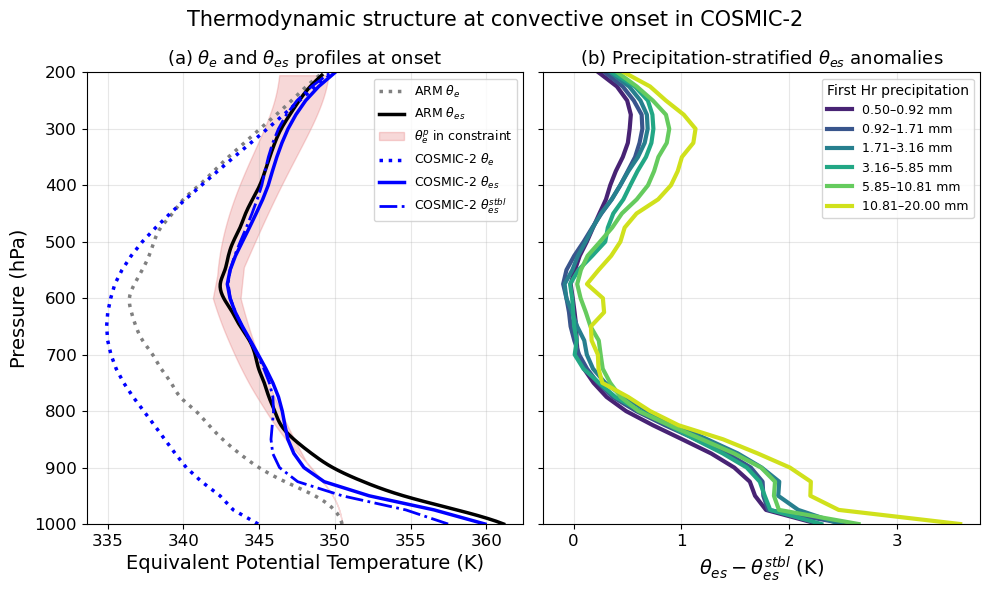

In [51]:
# Figure 4 from Emmenegger et al. 2026
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.colors import LogNorm

inds = np.digitize(pr_accum_2hr[beg_inds], bins=ac_bins) - 1
ref = np.nanmean(theta_es[pr_accum_2hr<.5], axis=0)
# inds = np.digitize(pr,bins=ac_bins)-1
# bin centers for coloring
ac_centers = 0.5 * (ac_bins[:-1] + ac_bins[1:])

norm = LogNorm(vmin=ac_bins[0], vmax=ac_bins[-1])
cmap = viridis

fig, ax = plt.subplots(1,2,figsize=(10, 6))

ax[0].plot(arm_e,levh,color='gray',ls=':',lw=lws,label=r'ARM $\theta_{e}$')
ax[0].plot(arm_es,levh,color='black',lw=lws,label=r'ARM $\theta_{es}$')
ax[0].fill_betweenx(levh,arm1,arm2,color='tab:red',\
                  alpha=.18,zorder=0,label=r'$\theta_e^p$ in constraint')
ax[0].plot(e_beg,lev/100,color='blue',lw=lws,ls=':',label=r'COSMIC-2 $\theta_{e}$')
ax[0].plot(es_beg,lev/100,color='blue',lw=lws,label=r'COSMIC-2 $\theta_{es}$')
ax[0].plot(ref,lev/100,color='blue', ls='-.', lw=lws-.5,label=r'COSMIC-2 $\theta_{es}^{stbl}$')

for i in range(len(ac_centers)):
    if np.sum(inds == i) < 50:
        continue

    color = cmap(norm(ac_centers[i]))
    # ax.plot(
    #     np.nanmean(theta_es[inds == i], axis=0) - ref,
    #     lev / 100,
    #     color=color,
    #     lw=2,
    #     label=f"{ac_bins[i]:.2f}–{ac_bins[i+1]:.2f} mm"
    # )
    ax[1].plot(
        np.nanmean(theta_es[beg_inds][inds == i], axis=0) - ref,
        lev / 100,
        color=color,
        lw=lws+.5,
        label=f"{ac_bins[i]:.2f}–{ac_bins[i+1]:.2f} mm"
    )
ax[0].set_xlabel('Equivalent Potential Temperature (K)')
ax[0].set_ylim(1000, 200)
ax[1].set_ylim(1000, 200)
ax[1].set_xlabel(r"$\theta_{es}-\theta_{es}^{stbl}$ (K)")
ax[0].set_ylabel("Pressure (hPa)")
ax[1].grid(True, alpha=0.3)
ax[0].grid(True, alpha=0.3)
ax[1].set_yticklabels([])
ax[1].legend(
    title="First Hr precipitation",
    fontsize=9,
    title_fontsize=10,
    loc="best"
)
ax[0].legend(
    fontsize=9,
    loc="best"
)
fig.suptitle("Thermodynamic structure at convective onset in COSMIC-2", y=0.98,fontsize=15)
ax[0].set_title("(a) $\\theta_e$ and $\\theta_{es}$ profiles at onset",fontsize=13,
    pad=6
)

ax[1].set_title(
    "(b) Precipitation-stratified $\\theta_{es}$ anomalies",
    fontsize=13,
    pad=6
)
plt.tight_layout()
plt.show()